In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm

In [2]:
import os, glob
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind, skew, kurtosis

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

print("Total images found:", len(all_imgs))
print("Sample:", all_imgs[:5])

Total images found: 760
Sample: ['/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1024).jpg', '/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (566).jpg']


**Labeling (same rule)**

In [5]:
def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

imgs = [p for p,l in pairs]
y = np.array([l for p,l in pairs])

print("Labeled:", len(imgs))
print("Class counts (0=Normal,1=Jaundice):", np.bincount(y))

Labeled: 760
Class counts (0=Normal,1=Jaundice): [560 200]


Chest ROI (Core change)

Chest region = middle-lower torso crop (Different from forehead)।

In [6]:
def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]

    # central width 50%
    x1 = int(0.25 * w)
    x2 = int(0.75 * w)

    # chest zone (middle-lower)
    y1 = int(0.40 * h)
    y2 = int(0.80 * h)

    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

Preprocess (same as Forehead)

5A) Gray-world white balance

In [7]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

5B) CLAHE on L channel (Lab)

In [8]:
def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

Skin Mask (HSV-based)

In [9]:
def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

7) Biomedical Feature Extraction (Same as Forehead)

In [10]:
def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    if Hvals.size > 30:
        hist, _ = np.histogram(Hvals, bins=18, range=(0,180))
        hue_peak = float(np.argmax(hist))
    else:
        hue_peak = np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,

        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,

        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,

        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }
    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

8) Build Chest Feature Dataset

In [11]:
rows = []
failed = 0

for p, label in tqdm(pairs, total=len(pairs)):
    img = cv2.imread(p)
    if img is None:
        failed += 1
        continue

    roi = extract_chest_roi(img)
    if roi is None:
        failed += 1
        continue

    feats = extract_features_from_roi(roi)
    feats["label"] = int(label)
    feats["path"] = p
    rows.append(feats)

feat_df_chest = pd.DataFrame(rows)

print("Chest features:", feat_df_chest.shape)
print("Failed:", failed)
print("Label distribution:\n", feat_df_chest["label"].value_counts())
feat_df_chest.head()

100%|██████████| 760/760 [03:44<00:00,  3.39it/s]

Chest features: (760, 29)
Failed: 0
Label distribution:
 label
0    560
1    200
Name: count, dtype: int64


,R_mean,G_mean,B_mean,R_std,G_std,B_std,R_p90,G_p90,B_p90,YGI,...,V_std,Hue_peak_bin,L_mean,a_mean,Lab_b_mean,Lab_b_p90,yellow_prop,YGI_x_b,label,path
0,134.142670,118.927879,105.965469,32.049362,33.090805,33.283230,171.0,158.0,147.0,2.388236,...,32.049370,1.0,129.412354,131.819199,137.379990,141.000000,0.202544,328.095834,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
1,157.926437,118.494286,97.232307,41.720108,37.747543,36.736500,204.0,160.0,139.0,2.842890,...,41.720108,1.0,134.639633,140.677612,145.785629,150.097656,0.160306,414.452456,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
2,136.184891,118.531975,111.801331,37.727768,39.138462,41.593983,183.0,167.0,163.0,2.278299,...,37.728050,0.0,129.648773,133.866882,134.412262,139.000000,0.242816,306.231326,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
3,140.447540,122.934547,112.462341,42.905632,46.369160,45.855713,189.0,175.0,163.0,2.341958,...,42.905678,0.0,133.480713,133.332657,136.406113,143.000000,0.208695,319.457393,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...
4,105.833977,81.996849,77.343880,36.368637,34.917877,33.993130,153.0,128.0,122.0,2.428516,...,36.368637,0.0,93.716095,137.321625,134.641113,138.000000,0.233345,326.978053,0,/content/drive/MyDrive/MACHINE LEARNING_LAB_II...


Correlation Matrix + Heatmap (with values)

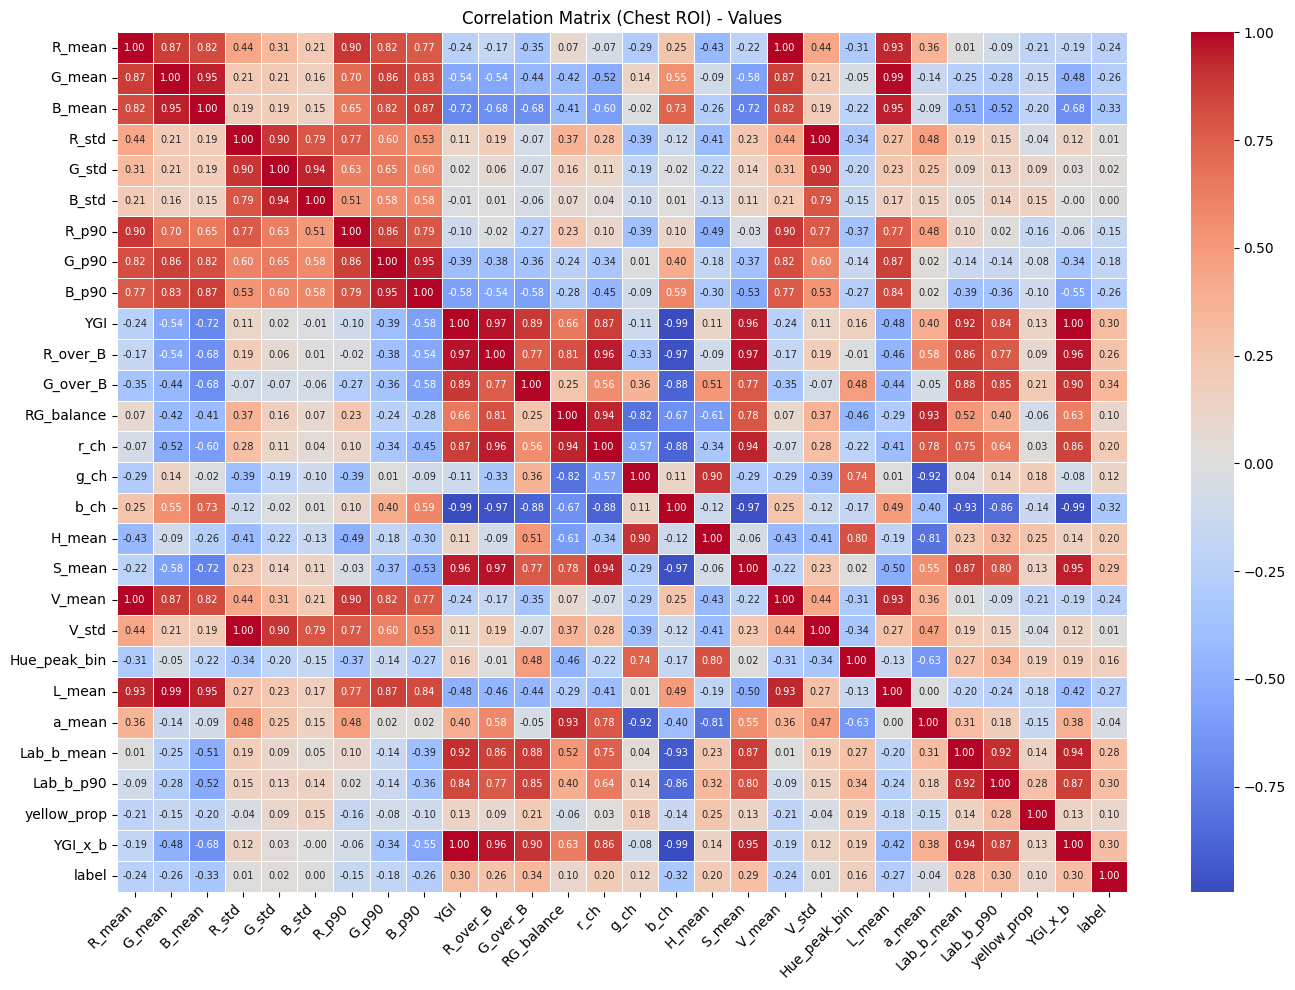

Correlation with label (sorted):
G_over_B        0.336
YGI             0.302
YGI_x_b         0.298
Lab_b_p90       0.296
S_mean          0.291
Lab_b_mean      0.284
R_over_B        0.261
r_ch            0.204
H_mean          0.201
Hue_peak_bin    0.163
g_ch            0.118
yellow_prop     0.100
RG_balance      0.097
G_std           0.023
V_std           0.012
R_std           0.011
B_std           0.004
a_mean         -0.036
R_p90          -0.152
G_p90          -0.181
R_mean         -0.236
V_mean         -0.236
G_mean         -0.261
B_p90          -0.263
L_mean         -0.266
b_ch           -0.316
B_mean         -0.328
Name: label, dtype: float64


In [12]:
corr = feat_df_chest.drop(columns=["path"]).corr(numeric_only=True)

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, linecolor="white", annot_kws={"size":7})
plt.title("Correlation Matrix (Chest ROI) - Values")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

label_corr = corr["label"].drop("label").sort_values(ascending=False)
print("Correlation with label (sorted):")
print(label_corr.round(3))

t-test p-values (Chest)

In [13]:
results = []
for col in feat_df_chest.columns:
    if col in ["label","path"]:
        continue
    c0 = feat_df_chest[feat_df_chest["label"]==0][col].dropna()
    c1 = feat_df_chest[feat_df_chest["label"]==1][col].dropna()
    if len(c0) < 10 or len(c1) < 10:
        continue
    t_stat, p_val = ttest_ind(c0, c1, equal_var=False)
    results.append({
        "Feature": col,
        "Mean_0": float(np.mean(c0)),
        "Mean_1": float(np.mean(c1)),
        "t_stat": float(t_stat),
        "p_value": float(p_val)
    })

ttest_df_chest = pd.DataFrame(results).sort_values("p_value")
ttest_df_chest["significant(p<0.05)"] = ttest_df_chest["p_value"] < 0.05

print(ttest_df_chest.head(15).round(6))

       Feature      Mean_0      Mean_1     t_stat  p_value  \
2       B_mean   96.872473   83.779246  10.570308      0.0   
11    G_over_B    1.142075    1.204851  -9.630442      0.0   
15        b_ch    0.285001    0.272352   9.396936      0.0   
24   Lab_b_p90  143.796603  147.230000  -8.826405      0.0   
9          YGI    2.522172    2.684853  -8.782994      0.0   
26     YGI_x_b  350.335526  378.819613  -8.696946      0.0   
17      S_mean   72.823015   86.714299  -8.606085      0.0   
23  Lab_b_mean  138.623129  140.861226  -8.484079      0.0   
21      L_mean  121.689511  111.855933   8.310977      0.0   
1       G_mean  109.756391  100.270782   8.045875      0.0   
8        B_p90  139.898207  128.235000   7.966607      0.0   
10    R_over_B    1.380097    1.480002  -7.389520      0.0   
18      V_mean  131.850868  122.446762   7.309259      0.0   
0       R_mean  131.850650  122.446503   7.309217      0.0   
16      H_mean   11.827207   13.399528  -5.697504      0.0   

    sig

PCA 3D (Chest)

Explained variance: [0.41705425 0.29129858 0.13790786]


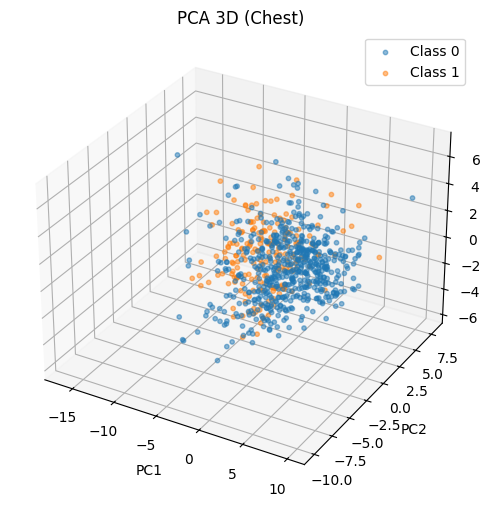

In [14]:
X = feat_df_chest.drop(columns=["label","path"])
y = feat_df_chest["label"]

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
print("Explained variance:", pca.explained_variance_ratio_)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")
for lab in [0,1]:
    sub = X_pca[y==lab]
    ax.scatter(sub[:,0], sub[:,1], sub[:,2], s=10, alpha=0.5, label=f"Class {lab}")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_zlabel("PC3")
ax.set_title("PCA 3D (Chest)")
ax.legend()
plt.show()

Explained variance (2D PCA): [0.41705425 0.29129858]


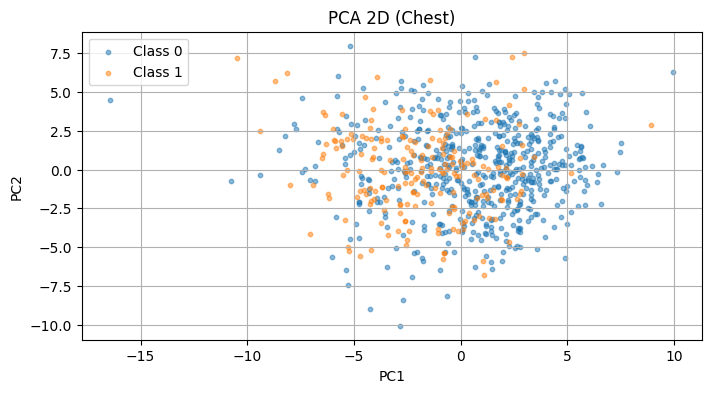

In [15]:
X = feat_df_chest.drop(columns=["label","path"])
y = feat_df_chest["label"]

X_scaled = StandardScaler().fit_transform(X)
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print("Explained variance (2D PCA):", pca_2d.explained_variance_ratio_)

plt.figure(figsize=(8,4))
for lab in [0,1]:
    sub = X_pca_2d[y==lab]
    plt.scatter(sub[:,0], sub[:,1], s=10, alpha=0.5, label=f"Class {lab}")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("PCA 2D (Chest)")
plt.legend()
plt.grid(True)
plt.show()

Final Chest Model (SVM) + ROC/AUC + CV

Significant features (Chest): ['B_mean', 'G_over_B', 'b_ch', 'Lab_b_p90', 'YGI', 'YGI_x_b', 'S_mean', 'Lab_b_mean', 'L_mean', 'G_mean', 'B_p90', 'R_over_B', 'V_mean', 'R_mean', 'H_mean', 'r_ch', 'G_p90', 'Hue_peak_bin', 'R_p90', 'yellow_prop', 'g_ch', 'RG_balance']
              precision    recall  f1-score   support

           0       0.85      0.69      0.76       112
           1       0.43      0.65      0.51        40

    accuracy                           0.68       152
   macro avg       0.64      0.67      0.64       152
weighted avg       0.74      0.68      0.69       152

Confusion Matrix:
 [[77 35]
 [14 26]]
Chest AUC: 0.75


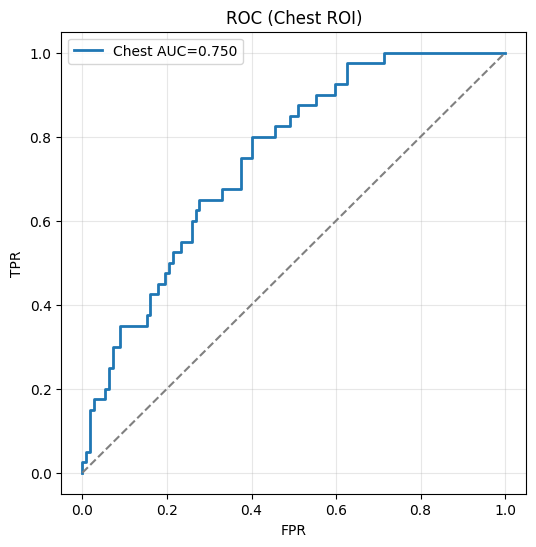

5-Fold CV AUC: [0.72767857 0.69776786 0.68816964 0.76584821 0.76205357]
Mean CV AUC: 0.7283035714285714


In [16]:
sig_feats_chest = ttest_df_chest[ttest_df_chest["p_value"] < 0.05]["Feature"].tolist()
print("Significant features (Chest):", sig_feats_chest)

Xsig = feat_df_chest[sig_feats_chest]
y = feat_df_chest["label"]

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

X_train, X_test, y_train, y_test = train_test_split(
    Xsig, y, test_size=0.2, random_state=42, stratify=y
)

svm.fit(X_train, y_train)
pred = svm.predict(X_test)
prob = svm.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
print("Chest AUC:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Chest AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC (Chest ROI)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

cv_auc = cross_val_score(svm, Xsig, y, cv=5, scoring="roc_auc")
print("5-Fold CV AUC:", cv_auc)
print("Mean CV AUC:", cv_auc.mean())

Brier score + 95% CI for Brier

In [17]:
from sklearn.metrics import brier_score_loss
from sklearn.utils import resample
import numpy as np

# Brier Score
bs = brier_score_loss(y_test, prob)
print(f"Chest Brier Score: {bs:.4f}")

# 95% CI for Brier using bootstrap
n_iterations = 2000
brier_scores_bootstrap = []

for i in range(n_iterations):
    y_res, prob_res = resample(
        np.array(y_test),
        np.array(prob),
        stratify=np.array(y_test),
        random_state=i
    )
    bs_res = brier_score_loss(y_res, prob_res)
    brier_scores_bootstrap.append(bs_res)

lower_brier = np.percentile(brier_scores_bootstrap, 2.5)
upper_brier = np.percentile(brier_scores_bootstrap, 97.5)

print(f"95% CI for Brier Score: [{lower_brier:.4f}, {upper_brier:.4f}]")

Chest Brier Score: 0.1687
95% CI for Brier Score: [0.1483, 0.1892]


95% CI for AUC

In [18]:
from sklearn.metrics import roc_auc_score
import numpy as np

def auc_bootstrap_ci(y_true, y_prob, n_boot=2000, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)

    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        y_b = y_true[idx]
        p_b = y_prob[idx]

        # skip bootstrap samples with only one class
        if len(np.unique(y_b)) < 2:
            continue

        aucs.append(roc_auc_score(y_b, p_b))

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)
    return lower, upper

auc_ci_low, auc_ci_high = auc_bootstrap_ci(y_test, prob)
print(f"Chest Test AUC: {roc_auc:.4f}")
print(f"95% CI for AUC: [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")

Chest Test AUC: 0.7500
95% CI for AUC: [0.6637, 0.8285]


Youden threshold

In [19]:
from sklearn.metrics import roc_curve
import numpy as np

fpr, tpr, thresholds = roc_curve(y_test, prob)
youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
youden_thr = thresholds[best_idx]

print(f"Youden threshold: {youden_thr:.4f}")

Youden threshold: 0.1898


Find all metrics at Youden threshold

In [20]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

y_pred_youden = (np.array(prob) >= youden_thr).astype(int)
cm_youden = confusion_matrix(y_test, y_pred_youden)

tn, fp, fn, tp = cm_youden.ravel()

acc_youden = accuracy_score(y_test, y_pred_youden)
prec_youden = precision_score(y_test, y_pred_youden, zero_division=0)
rec_youden = recall_score(y_test, y_pred_youden, zero_division=0)
spec_youden = tn / (tn + fp)
f1_youden = f1_score(y_test, y_pred_youden, zero_division=0)

print("Chest — Metrics at Youden threshold")
print(f"Threshold: {youden_thr:.4f}")
print(f"Accuracy: {acc_youden:.4f}")
print(f"Precision: {prec_youden:.4f}")
print(f"Recall: {rec_youden:.4f}")
print(f"Specificity: {spec_youden:.4f}")
print(f"F1-score: {f1_youden:.4f}")
print(f"Confusion matrix: {cm_youden.tolist()}")

Chest — Metrics at Youden threshold
Threshold: 0.1898
Accuracy: 0.6513
Precision: 0.4156
Recall: 0.8000
Specificity: 0.5982
F1-score: 0.5470
Confusion matrix: [[67, 45], [8, 32]]


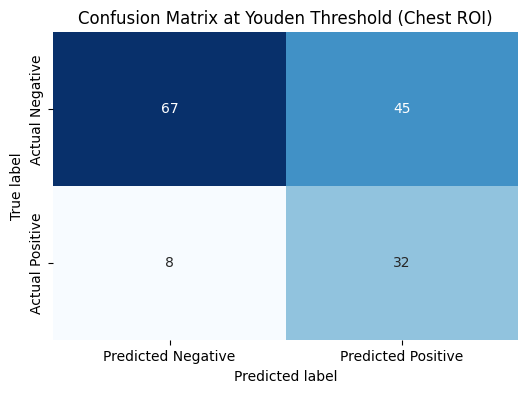

In [22]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_youden, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Predicted Negative", "Predicted Positive"],
            yticklabels=["Actual Negative", "Actual Positive"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix at Youden Threshold (Chest ROI)")
plt.show()

Final plain summary print

In [23]:
print("\nCH SVM — Table 1")
print(f"Test AUC: {roc_auc:.4f}")
print(f"95% CI (AUC): [{auc_ci_low:.4f}, {auc_ci_high:.4f}]")
print(f"Brier score: {bs:.4f}")
print(f"95% CI (Brier): [{lower_brier:.4f}, {upper_brier:.4f}]")

print("\nCH SVM — Table 2 (Youden J)")
print("Threshold rule: Youden J")
print(f"Threshold: {youden_thr:.4f}")
print(f"Accuracy: {acc_youden:.4f}")
print(f"Precision: {prec_youden:.4f}")
print(f"Recall: {rec_youden:.4f}")
print(f"Specificity: {spec_youden:.4f}")
print(f"F1-score: {f1_youden:.4f}")
print(f"Confusion matrix: {cm_youden.tolist()}")


CH SVM — Table 1
Test AUC: 0.7500
95% CI (AUC): [0.6637, 0.8285]
Brier score: 0.1687
95% CI (Brier): [0.1483, 0.1892]

CH SVM — Table 2 (Youden J)
Threshold rule: Youden J
Threshold: 0.1898
Accuracy: 0.6513
Precision: 0.4156
Recall: 0.8000
Specificity: 0.5982
F1-score: 0.5470
Confusion matrix: [[67, 45], [8, 32]]
